# Pauli KED — Functional Profile Demo

This notebook demonstrates how to use the `pauliked` package to compute and
visualise the **scaled Pauli kinetic-energy density** and the
**scaled Pauli potential** for a spherical atom.

Two built-in functionals from Perdew & Constantin are shown:
- `Fpc` — Perdew–Constantin (2007)
- `F_RPP` — Reparametrised Perdew–Constantin

Both are compared against the exact Kohn–Sham reference.

---

### How to use this notebook

1. **Install the package** (once, from the project root):
   ```
   pip install -e .
   ```
2. **Get the data**: You need an all-electron data file named `ae_totals_<atom>.dat`.
   Place it in a directory and set `data_dir` below to point there.
3. **Set three variables** in the Configuration cell: `atom`, `Z`, and `data_dir`.
4. **Run all cells** — you'll get two plots comparing your functionals against the exact KS result.

### Want to use your own functional?

Any function with this signature works:

```python
def my_functional(s_sqr, q, *args):
    """
    Parameters
    ----------
    s_sqr : array  — reduced density gradient squared
    q     : array  — reduced Laplacian

    Returns
    -------
    F      : array  — enhancement factor
    dF_ds2 : array  — derivative of F w.r.t. s²
    dF_dq  : array  — derivative of F w.r.t. q
    """
    ...
    return F, dF_ds2, dF_dq
```

See `pauliked/pc_functional.py` for examples (`Fpc`, `Fpcopt`, `F_RPP`).
Then just add it to the `functionals` dictionary in cell 3 below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pauliked import (
    read_aetotals,
    Potential,
    RadialGradient,
    RadialLaplacian,
    get_tautf,
    Ft,
    FvW,
    F_pc,
    F_RPP,
)

## 1. Configuration

Set the atom name, atomic number, and the path to the directory that
contains your `ae_totals_<atom>.dat` file.

In [2]:
atom = "Ar"
Z    = 10

# Point this to wherever your Totals data lives.
data_dir = "ae/"

# Stencil parameters for numerical derivatives
nn = 5     # interpolation half-width
mm = 3     # binomial smoothing half-width

## 2. Read data and compute derivatives

In [3]:
r, ntot, tauks, vpexact, vr = read_aetotals(atom, indirectory=data_dir)

# Trim endpoints to avoid numerical boundary artefacts
nmin, nmax = 100, -20
r       = r[nmin:nmax]
ntot    = ntot[nmin:nmax]
tauks   = tauks[nmin:nmax]
vpexact = vpexact[nmin:nmax]

# Radial derivatives of the density
grad_n = RadialGradient(ntot, r, nn, mm)
lapl_n = RadialLaplacian(ntot, r, nn, mm)

# Thomas-Fermi baseline
tautf, _ = get_tautf(ntot)

# Scaled radial coordinate
rscale = Z ** (1.0 / 3.0) * r

print(f"Grid: {len(r)} points,  r = [{r[0]:.4e}, {r[-1]:.4e}]")

#Atom:Ar
#File read: ae/ae_totals_Ar.dat
Grid: 346 points,  r = [3.9836e-03, 1.8037e+01]


## 3. Compute KED and potential for each functional

In [4]:
# von Weizsäcker baseline (needed to isolate the Pauli part)
vwKED, vw1, vw2, vw3, _ = Potential(r, ntot, grad_n, lapl_n, FvW, nn, mm)
vw = vw1 - vw2 + vw3

functionals = {
    "PC (Perdew–Constantin)": F_pc,
    "RPP (Reparametrised)": F_RPP,
}

results = {}
for name, func in functionals.items():
    KED, v1, v2, v3, E = Potential(r, ntot, grad_n, lapl_n, func, nn, mm)
    v = v1 - v2 + v3
    results[name] = {"KED": KED, "v": v}

## 4. Scaled Pauli KED

$F_p = (\tau_{\text{model}} - \tau_{\text{vW}}) \;/\; \tau_{\text{TF}}$
plotted against $\ln(Z^{1/3}\, r)$.

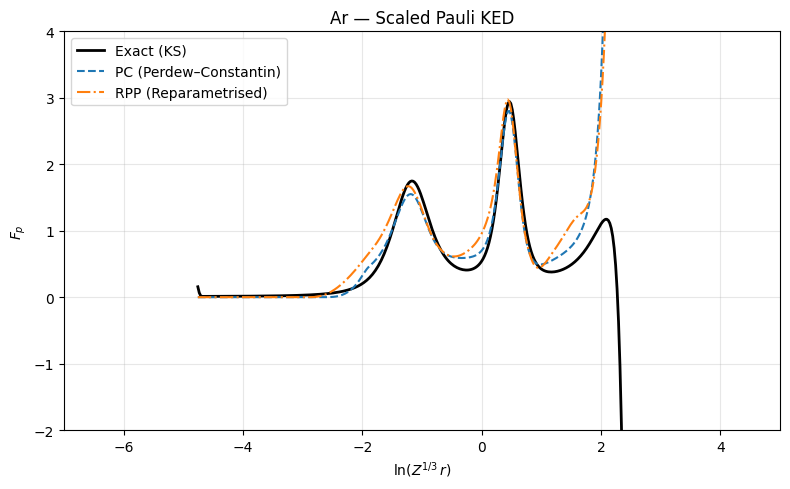

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.log(rscale)

# Exact reference
ax.plot(x, (tauks - vwKED) / tautf, "k-", lw=2, label="Exact (KS)")

# Functional curves
styles = ["--", "-.", ":"]
for i, (name, res) in enumerate(results.items()):
    fp = (res["KED"] - vwKED) / tautf
    ax.plot(x, fp, styles[i % len(styles)], lw=1.5, label=name)

ax.set_xlabel(r"$\ln(Z^{1/3}\, r)$")
ax.set_ylabel(r"$F_p$")
ax.set_title(f"{atom} — Scaled Pauli KED")
ax.set_xlim(-7, 5)
ax.set_ylim(-2, 4)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Scaled Pauli Potential

$n \, v_p \;/\; \tau_{\text{TF}}$
plotted against $\ln(Z^{1/3}\, r)$.

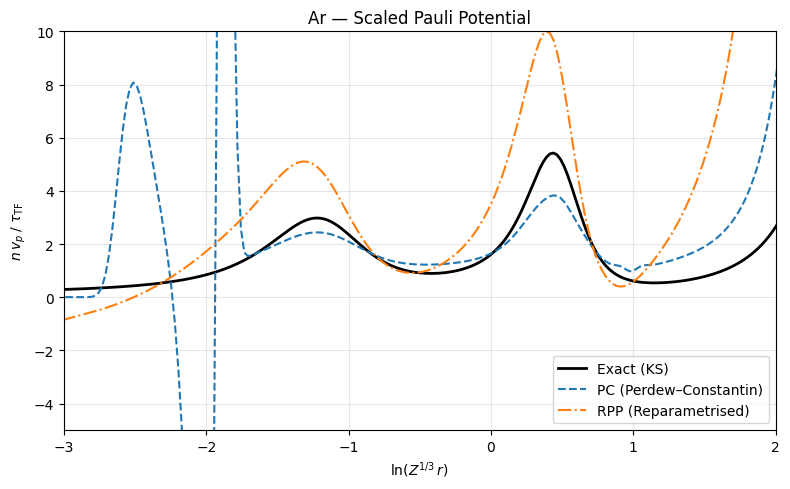

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.log(rscale)

# Exact reference
ax.plot(x, vpexact * ntot / tautf, "k-", lw=2, label="Exact (KS)")

# Functional curves
for i, (name, res) in enumerate(results.items()):
    vp = (res["v"] - vw) * ntot / tautf
    ax.plot(x, vp, styles[i % len(styles)], lw=1.5, label=name)

ax.set_xlabel(r"$\ln(Z^{1/3}\, r)$")
ax.set_ylabel(r"$n\, v_p \;/\; \tau_{\mathrm{TF}}$")
ax.set_title(f"{atom} — Scaled Pauli Potential")
ax.set_xlim(-3, 2)
ax.set_ylim(-5, 10)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Bring Your Own Functional

Define a function that takes `(s_sqr, q)` and returns `(F, dF/ds², dF/dq)`,
then drop it into the same workflow. Here's a minimal example:

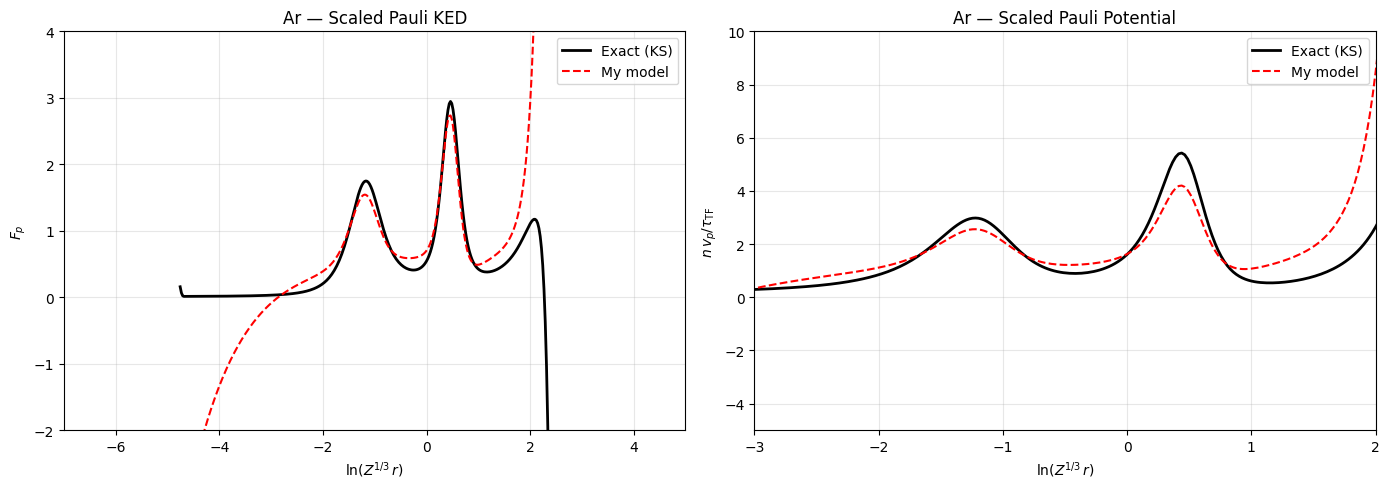

In [7]:
import numpy as np

def my_model(s_sqr, q, *args):
    """Toy example: second-order gradient expansion only."""
    s_sqr = np.asarray(s_sqr)
    F     = 1.0 + (5.0 / 27.0) * s_sqr + (20.0 / 9.0) * q
    dF_ds2 = (5.0 / 27.0) * np.ones_like(s_sqr)
    dF_dq  = (20.0 / 9.0) * np.ones_like(s_sqr)
    return F, dF_ds2, dF_dq

# Run it through the same pipeline
myKED, mv1, mv2, mv3, mE = Potential(r, ntot, grad_n, lapl_n, my_model, nn, mm)
my_v = mv1 - mv2 + mv3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.log(rscale)

# Scaled KED
ax1.plot(x, (tauks - vwKED) / tautf, "k-", lw=2, label="Exact (KS)")
ax1.plot(x, (myKED - vwKED) / tautf, "r--", lw=1.5, label="My model")
ax1.set(xlabel=r"$\ln(Z^{1/3}\, r)$", ylabel=r"$F_p$",
        title=f"{atom} — Scaled Pauli KED", xlim=(-7, 5), ylim=(-2, 4))
ax1.legend()
ax1.grid(alpha=0.3)

# Scaled Pauli potential
ax2.plot(x, vpexact * ntot / tautf, "k-", lw=2, label="Exact (KS)")
ax2.plot(x, (my_v - vw) * ntot / tautf, "r--", lw=1.5, label="My model")
ax2.set(xlabel=r"$\ln(Z^{1/3}\, r)$", ylabel=r"$n\, v_p / \tau_{\mathrm{TF}}$",
        title=f"{atom} — Scaled Pauli Potential", xlim=(-3, 2), ylim=(-5, 10))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()